## **Họ và tên: Võ Lê Phúc Thịnh**
## **MSSV: 2510382**

## Bài 1: Titanic Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_theme(style="whitegrid")

In [22]:
df = sns.load_dataset('titanic')
df.info()
display(df.head())

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

X = df[features]
y = df[target]

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=(15/85), stratify=y_tmp, random_state=42)

num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
    ("ord", "passthrough", ord_cols)
])

X_train_t = preprocess.fit_transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [26]:
logistic_regression = LogisticRegression(random_state=42, max_iter=1000)
logistic_regression.fit(X_train_t, y_train)
y_pred_logistic = logistic_regression.predict(X_test_t)

linear_regression = LinearRegression()
linear_regression.fit(X_train_t, y_train)
y_pred_linear_raw = linear_regression.predict(X_test_t)
y_pred_linear = (y_pred_linear_raw >= 0.5).astype(int)

def print_metrics(model_name, y_true, y_pred):
    print(f"Model: {model_name}")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred, zero_division=0):.4f}\n")

print_metrics("Logistic Regression", y_test, y_pred_logistic)
print_metrics("Linear Regression Baseline", y_test, y_pred_linear)

Model: Logistic Regression
Accuracy : 0.7761
Precision: 0.7442
Recall   : 0.6275
F1-score : 0.6809

Model: Linear Regression Baseline
Accuracy : 0.7612
Precision: 0.7021
Recall   : 0.6471
F1-score : 0.6735



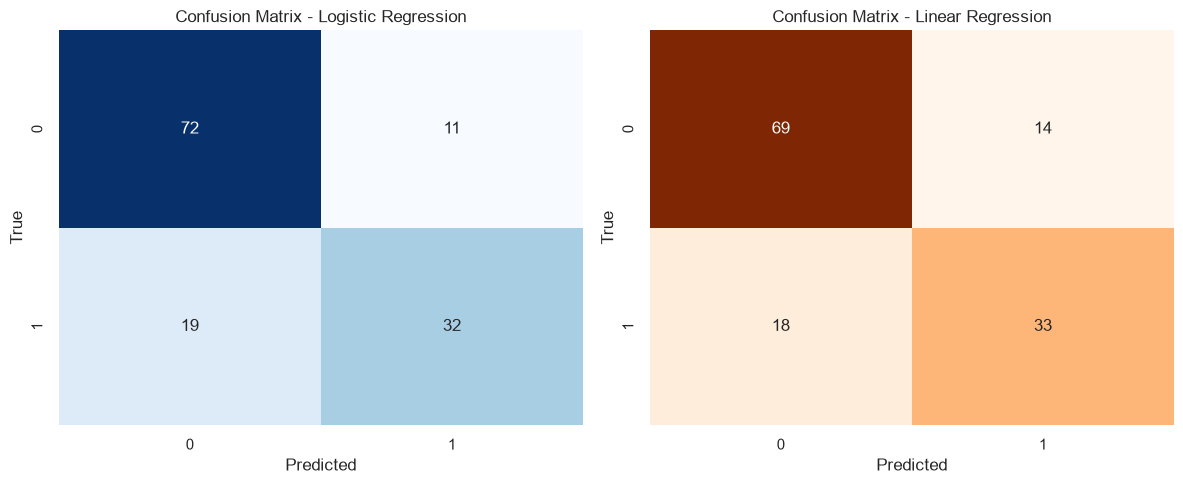

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_logistic = confusion_matrix(y_test, y_pred_logistic)
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

cm_linear = confusion_matrix(y_test, y_pred_linear)
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix - Linear Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

**Nhận xét:**
Mô hình linear khác biệt so với mô hình logistic ở việc linear tính toán dựa trên sai số sau đó cắt ngưỡng để phân loại, trong khi logistic phân loại dựa trên xác suất. Được thấy thêm đa số các metric đánh giá cho logistic đều cao hơn linear cho thấy dự đoán chính xác trong các dự đoán của mô hình logistic cũng như dự đoán đúng tổng thể. Vì vậy logistic regression phù hợp hơn với bài toán phân loại.

## Bài 2: Dry Bean Dataset

In [39]:
from pathlib import Path
TRAIN_CANDIDATES = [
    Path("dry_bean_train.csv"),
    Path("../Dry_Bean_Dataset/dry_bean_train.csv"),
    Path("Dry_Bean_Dataset/dry_bean_train.csv"),
]

TEST_CANDIDATES = [
    Path("dry_bean_test.csv"),
    Path("../Dry_Bean_Dataset/dry_bean_test.csv"),
    Path("Dry_Bean_Dataset/dry_bean_test.csv"),
]

TRAIN_PATH = next((p for p in TRAIN_CANDIDATES if p.exists()), None)
TEST_PATH = next((p for p in TEST_CANDIDATES if p.exists()), None)

if TRAIN_PATH is None or TEST_PATH is None:
    raise FileNotFoundError("Không tìm thấy file!")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

train_df.columns = train_df.columns.str.strip().str.lower().str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_")
test_df.columns = test_df.columns.str.strip().str.lower().str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_")

target = 'class'

train_df[target] = train_df[target].astype(str).str.strip().str.upper()
test_df[target] = test_df[target].astype(str).str.strip().str.upper()

train_df = train_df.dropna().drop_duplicates().reset_index(drop=True)
test_df = test_df.dropna().drop_duplicates().reset_index(drop=True)

features = [col for col in train_df.columns if col != target]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

display(X_train.head())

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4
0,69471,1069.638,399.100245,225.005782,1.773733,0.825923,71088,297.410868,0.707386,0.977254,0.763027,0.745203,0.005745,0.001093,0.555328,0.985004
1,82877,1162.581,391.817013,270.836144,1.446694,0.722634,84171,324.841921,0.825986,0.984627,0.770544,0.829065,0.004728,0.001378,0.687349,0.994384
2,65042,1023.506,419.202858,198.962774,2.106941,0.880190,65748,287.774298,0.783403,0.989262,0.780231,0.686480,0.006445,0.000883,0.471255,0.992906
3,41315,758.920,287.438268,183.447580,1.566869,0.769858,41704,229.355383,0.791930,0.990672,0.901417,0.797929,0.006957,0.001740,0.636691,0.997611
4,91088,1168.645,459.300729,253.950486,1.808623,0.833243,91799,340.553731,0.789051,0.992255,0.838119,0.741461,0.005042,0.000940,0.549765,0.994318


X_train shape: (10834, 16)
X_test shape: (2709, 16)


In [40]:
num_cols = features

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer([
    ("num", num_pipeline, num_cols)
])

X_train_t = preprocess.fit_transform(X_train)
X_test_t = preprocess.transform(X_test)

In [49]:
def print_metrics(model_name, y_true, y_pred):
    print(f"Model: {model_name}")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}\n")

logistic_pipeline = Pipeline([
    ("classifier", LogisticRegression(max_iter=3000, random_state=42))
])

knn_pipeline = Pipeline([
    ("classifier", KNeighborsClassifier(n_neighbors=7, weights='distance'))
])

logistic_pipeline.fit(X_train_t, y_train)
knn_pipeline.fit(X_train_t, y_train)

y_pred_log = logistic_pipeline.predict(X_test_t)
y_pred_knn = knn_pipeline.predict(X_test_t)

print_metrics("Logistic Regression", y_test, y_pred_log)
print_metrics("KNN", y_test, y_pred_knn)

Model: Logistic Regression
Accuracy : 0.9192
Precision: 0.9307
Recall   : 0.9300
F1-score : 0.9302

Model: KNN
Accuracy : 0.9136
Precision: 0.9268
Recall   : 0.9237
F1-score : 0.9250



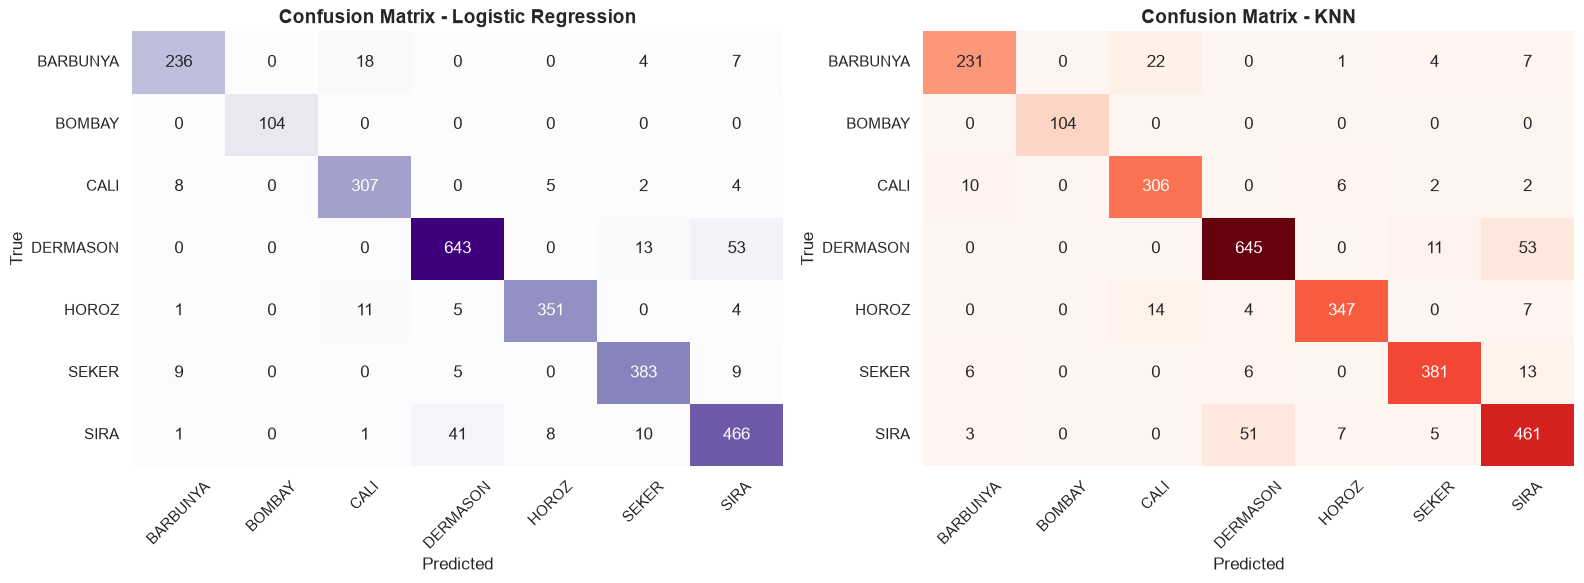

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels = sorted(y_test.unique())

cm_log = confusion_matrix(y_test, y_pred_log, labels=labels)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Purples', ax=axes[0], xticklabels=labels, yticklabels=labels, cbar=False)
axes[0].set_title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

cm_knn = confusion_matrix(y_test, y_pred_knn, labels=labels)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Reds', ax=axes[1], xticklabels=labels, yticklabels=labels, cbar=False)
axes[1].set_title('Confusion Matrix - KNN', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('True', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Nhận xét:**
Cả 2 mô hình đều cho ra kết quả đánh giá tương đồng nhau và đạt chỉ số khá cao. Tuy nhiên nếu xét một bộ dữ liệu lớn, mô hình KNN sẽ tiêu tốn nhiều thời gian và tài nguyên tính toán hơn. Đổi lại mô hình KNN sẽ tốt hơn Logistic nếu bộ dữ liệu có nhiều đặc điểm phức tạp lồng ghép nhau khiến cho việc tìm các bộ tham số cho Logistic trở nên khó khăn.